In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Caricamento dati
df = pd.read_csv("shampoo_sales.csv")

df.head()


,Date,Sales
0,01-01-2012,266.0
1,01-02-2012,145.9
2,01-03-2012,183.1
3,01-04-2012,119.3
4,01-05-2012,180.3


In [4]:
# Assegniamo un indice progressivo ai mesi (0, 1, 2, ...)
df["MonthIndex"] = range(len(df))


# X (maiuscola) per rappresentare la matrice delle feature (variabili indipendenti)
X = df[["MonthIndex"]].values
# y (minuscola) per rappresentare il vettore target (variabile dipendente)
y = df["Sales"].values

df

,Date,Sales,MonthIndex
0,01-01-2012,266.0,0
1,01-02-2012,145.9,1
2,01-03-2012,183.1,2
3,01-04-2012,119.3,3
4,01-05-2012,180.3,4
5,01-06-2012,168.5,5
6,01-07-2012,231.8,6
7,01-08-2012,224.5,7
8,01-09-2012,192.8,8
9,01-10-2012,122.9,9


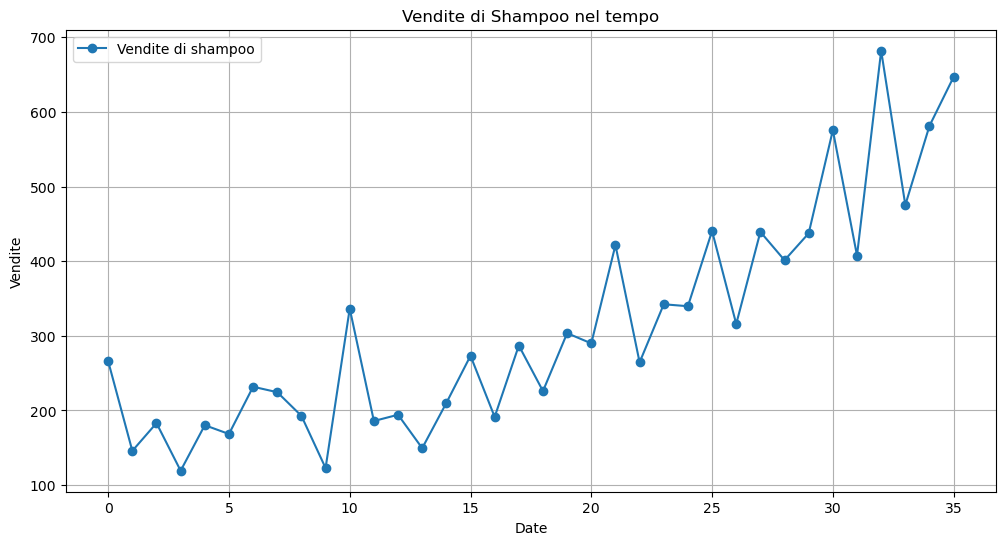

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(X, y, marker='o', linestyle='-', label='Vendite di shampoo')
plt.title('Vendite di Shampoo nel tempo')
plt.xlabel('Date')
plt.ylabel('Vendite')
plt.legend()
plt.grid(True)
plt.show()

DIVIDERE IL DATASET


In [6]:
#prima facevamo cosi: 6.3 pred

#qui ora si fa cosi

from sklearn.model_selection import train_test_split

# Divisione train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13],
       [14],
       [15],
       [16],
       [17],
       [18],
       [19],
       [20],
       [21],
       [22],
       [23],
       [24],
       [25],
       [26],
       [27]])

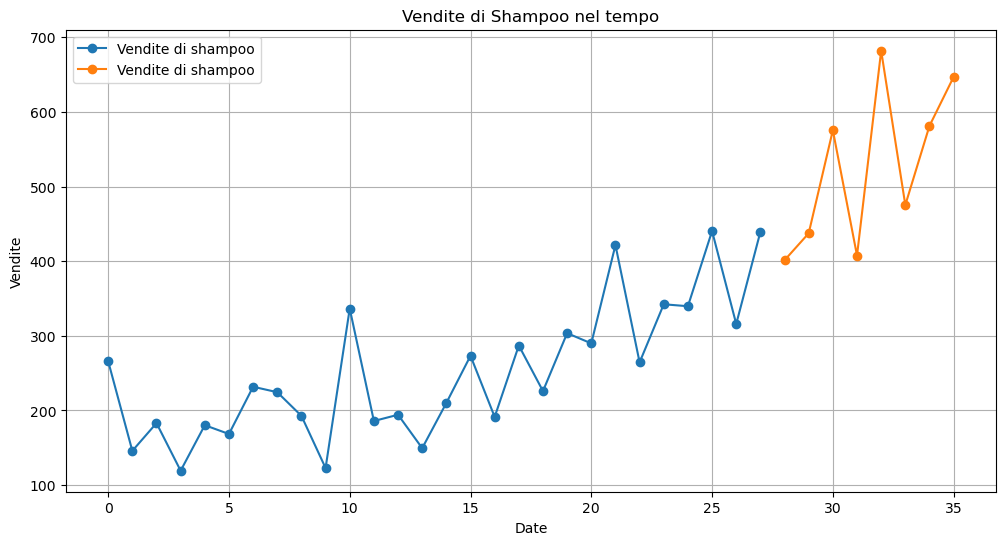

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(X_train, y_train, marker='o', linestyle='-', label='Vendite di shampoo')
plt.plot(X_test, y_test, marker='o', linestyle='-', label='Vendite di shampoo')
plt.title('Vendite di Shampoo nel tempo')
plt.xlabel('Date')
plt.ylabel('Vendite')
plt.legend()
plt.grid(True)
plt.show()

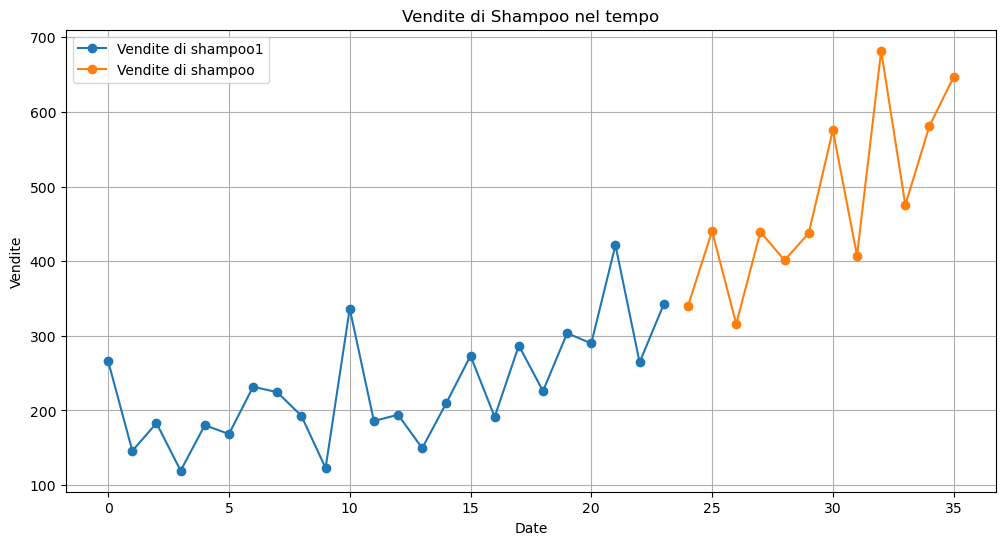

In [8]:
 #Split: prime 24 osservazioni per il training, il resto per il test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=24, shuffle=False)

plt.figure(figsize=(12, 6))
plt.plot(X_train, y_train, marker='o', linestyle='-', label='Vendite di shampoo1')
plt.plot(X_test, y_test, marker='o', linestyle='-', label='Vendite di shampoo')
plt.title('Vendite di Shampoo nel tempo')
plt.xlabel('Date')
plt.ylabel('Vendite')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
#train: creare modello
#validation: coalcol mae e rmse
#test: testare se il modello

REGRESSIONE: LinearRegression



In [10]:
from sklearn.linear_model import LinearRegression

# Regressione lineare
model_linear = LinearRegression()
model_linear.fit(X_train, y_train) #fitto i dati
y_pred_linear = model_linear.predict(X_test) #predico i dati sull'oggetto dove ho già fatto il fil

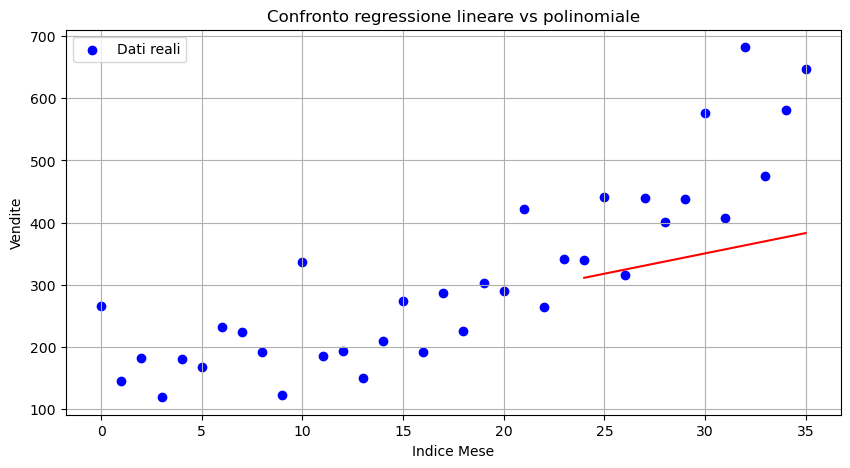

In [11]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Dati reali", color="blue")
plt.plot(X_test, y_pred_linear, color="red")
plt.xlabel("Indice Mese")
plt.ylabel("Vendite")
plt.title("Confronto regressione lineare vs polinomiale")
plt.legend()
plt.grid(True)
plt.show()

Polinomio di grado superiore : make_pipeline

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Regressione polinomiale grado 2

#linear regression fa la regressione dei dati trasformati
model_poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_poly2.fit(X_train, y_train)
y_pred_poly2 = model_poly2.predict(X_test)

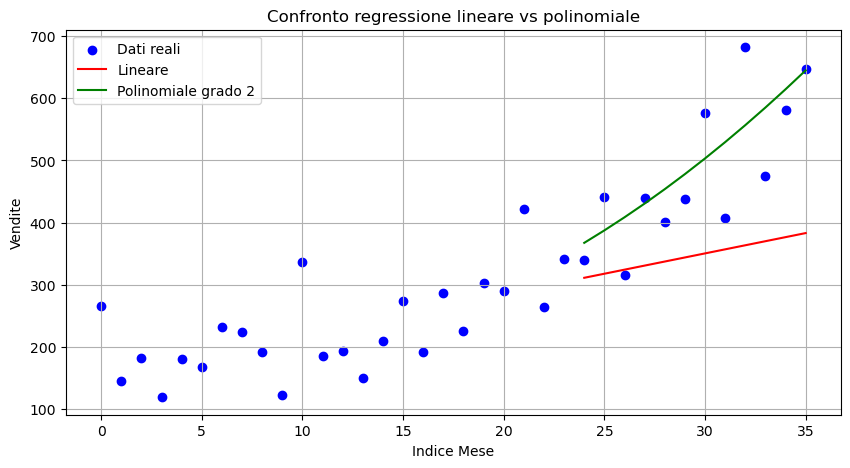

In [13]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Dati reali", color="blue")
plt.plot(X_test, y_pred_linear, label=f"Lineare", color="red")
plt.plot(X_test, y_pred_poly2, label=f"Polinomiale grado 2", color="green")
plt.xlabel("Indice Mese")
plt.ylabel("Vendite")
plt.title("Confronto regressione lineare vs polinomiale")
plt.legend()
plt.grid(True)
plt.show()

mean_absolute_error root_mean_squared_error è una funzione di scikit-learn che calcola direttamente MAE ed RMSE tra due insiemi di valori

In [15]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mae_poly2 =  mean_absolute_error(y_test, y_pred_poly2)
rmse_linear = root_mean_squared_error(y_test, y_pred_linear)
rmse_poly2 =  root_mean_squared_error(y_test, y_pred_poly2)

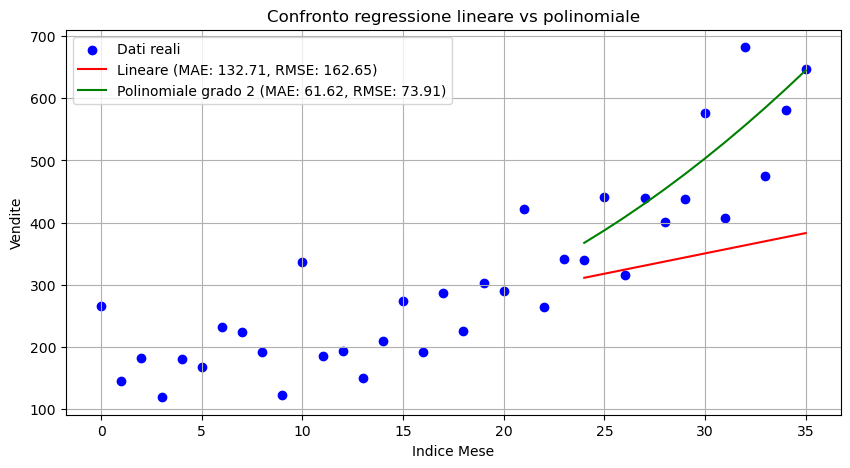

In [16]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Dati reali", color="blue")
plt.plot(X_test, y_pred_linear, label=f"Lineare (MAE: {mae_linear:.2f}, RMSE: {rmse_linear:.2f})", color="red")
plt.plot(X_test, y_pred_poly2, label=f"Polinomiale grado 2 (MAE: {mae_poly2:.2f}, RMSE: {rmse_poly2:.2f})", color="green")
plt.xlabel("Indice Mese")
plt.ylabel("Vendite")
plt.title("Confronto regressione lineare vs polinomiale")
plt.legend()
plt.grid(True)
plt.show()

PLOTLY


In [17]:
import pandas as pd
import seaborn as sns

from pandas.plotting import scatter_matrix
from matplotlib import pyplot as plotly  # NB: attenzione: qui si sta rinominando pyplot come 'plotly'
from matplotlib import font_manager as font_manager
from datetime import datetime, timedelta
import numpy as np


import plotly.figure_factory as ff

grafico con una linea

In [18]:
import plotly.express as px

df = pd.read_csv("shampoo_sales.csv")
df["MonthIndex"] = range(len(df))
df.head()

,Date,Sales,MonthIndex
0,01-01-2012,266.0,0
1,01-02-2012,145.9,1
2,01-03-2012,183.1,2
3,01-04-2012,119.3,3
4,01-05-2012,180.3,4


In [19]:
fig = px.line(df, x="MonthIndex", y = "Sales", title = "Vendite Mensili di shampi" )

fig.show()

GRAFICO CON PIù LINEE E MARCATORI

In [20]:
import plotly.graph_objects as go

# Nomi di studenti
studenti = ['Giulia', 'Marco', 'Elena', 'Luca']

# Voti in diverse materie (in trentesimi)
italiano = [28, 25, 30, 27]
matematica = [26, 29, 24, 30]
informatica = [30, 28, 29, 27]
storia = [27, 26, 28, 30]

fig = go.Figure()

fig.add_trace(go.Scatter(x=studenti, y=italiano, name="Italiano",
                         mode='lines+markers',
                         line=dict(color="blue", width=4)))

fig.add_trace(go.Scatter(x=studenti, y=matematica, name="Matematica",
                         mode='lines+markers',
                         line=dict(color="red", width=4)))

fig.add_trace(go.Scatter(x=studenti, y=informatica, name="Informatica",
                         mode='lines+markers',
                         line=dict(color="green", width=4, dash='dash')))

fig.add_trace(go.Scatter(x=studenti, y=storia, name="Storia",
                         mode='lines+markers',
                         line=dict(color="firebrick", width=4, dash='dot')))

fig.update_layout(
    title="Voti degli studenti",
    xaxis_title="Studente",
    yaxis_title="Voto",
    yaxis=dict(range=[20, 31])
)

fig.show()

Utile quando:

Hai più variabili da confrontare su un insieme comune (es. studenti, anni, prodotti...).
Vuoi una visualizzazione compatta, leggibile, e con dettagli sui punti.

In [21]:
# Simula voti casuali (18–30) per 20 studenti e 6 materie
np.random.seed(0)
studenti = [f'Studente {i}' for i in range(1, 21)]
materie = ['Italiano', 'Matematica', 'Storia', 'Inglese', 'Fisica', 'Informatica']
voti = np.random.randint(18, 31, size=(20, len(materie)))

# Crea la heatmap
fig = go.Figure(data=go.Heatmap(
    z=voti,
    x=materie,
    y=studenti,
    colorscale='YlGnBu',
    zmin=18,
    zmax=30,
    colorbar=dict(title='Voto')
))

fig.update_layout(
    title='Voti degli studenti per materia',
    xaxis_title='Materia',
    yaxis_title='Studente'
)

fig.show()

BAR PLOT

In [22]:
df = sns.load_dataset('titanic')
df.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [23]:
fig = px.histogram(df, x='pclass', color='sex', barmode='group',
                   title='Numero di passeggeri per classe e sesso')
fig.show()

In [ ]:
# Area Chart
fig = px.area(df, x='sex', y='age', color='survived',
              title="AREA SU COME VARIA RISPETTO AL SESSO E L'ETA")

fig.show()

#COLORE E' AL FATTO CHE SIANO SOPRAVVISUTI O NO 

In [25]:
# Stacked area chart
stud = ['Rave', 'Leo', 'Steve']

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=stud, y=[40, 10, 20],
    hoverinfo='x+y',
    mode='lines',
    line=dict(width=0.6, color='rgb(172,89,200)'),
    stackgroup='one'
))

fig.add_trace(go.Scatter(
    x=stud, y=[50, 5, 2],
    hoverinfo='x+y',
    mode='lines',
    line=dict(width=0.6, color='rgb(100,51,190)'),
    stackgroup='one'
))

fig.show()

In [32]:
# Pie chart
stud = ['Leo', 'Steve', 'Claire', 'Caprio', 'Sharman', 'Kiya']
marks = [34, 56, 76, 87, 45, 90, 91]

# Assicurati che la lunghezza di 'LABELS' corrisponda a quella di 'stud'
fig = go.Figure(data=[
    go.Pie(
        labels=stud,
        values=marks,
        pull=[0, 0, 0, 0.2, 0, 0]  # Caprio evidenziato
    )
])

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title="Students and their marks")

fig.show()

In [33]:
# Dati
stud = ['Leo', 'Steve', 'Claire', 'Caprio', 'Sharman', 'Kiya']
teacher = ['Steve', "", 'Caprio', 'Leo', 'Steve', 'Sharman']
marks = [34, 56, 76, 87, 45, 90]

# Sunburst chart
fig = go.Figure(go.Sunburst(
    labels=stud,
    parents=teacher,
    values=marks
))

fig.update_layout(margin=dict(t=1, l=1, r=1, b=1))
fig.show()

In [34]:
labels = ["World", "Europe", "Italy", "Rome", "Milan"]
parents = ["", "World", "Europe", "Italy", "Italy"]
values = [150, 100, 70, 40, 30]  # 40+30=70 (ok), 70+30=100 (ok), ecc.

fig = go.Figure(go.Sunburst(
    labels=labels,
    parents=parents,
    values=values,
    branchvalues='total'  # tutti i genitori includono il valore dei figli
))

fig.update_layout(margin=dict(t=0, l=0, r=0, b=0))
fig.show()

In [35]:
import plotly.express as px

df = sns.load_dataset('iris')  
# va bene anche  px.data.iris()
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [40]:
fig = px.scatter(df.head(), x="sepal_width", y="sepal_length", color="species")
fig.show()

In [45]:
# Caricamento dataset Iris
iris = sns.load_dataset('iris')  # oppure: pd.read_csv(...) se usi un file
print(iris.head())
# Scatter plot
fig = px.scatter(
    iris.head(),
    x="petal_length",
    y="petal_width",
    color="species",
    size="sepal_width",
    hover_data=['sepal_length'],
    title="Scatter plot of Iris Dataset"
)

fig.show()

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [38]:
# Genera griglia di punti
x = np.linspace(-6, 6, 100)
y = np.linspace(-6, 6, 100)
x, y = np.meshgrid(x, y)

# Definisce la funzione
z = np.sinc(np.sqrt(x**2 + y**2) / np.pi)  # sinc(x) = sin(pi x)/(pi x)

# Crea la figura 3D
fig = go.Figure(data=[go.Surface(z=z, x=x, y=y, colorscale='Viridis')])

fig.update_layout(
    title='Superficie 3D: sinc(sqrt(x² + y²))',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z'
    )
)

fig.show()

DASH

Facciamo un'interfaccia che mostra uno slider interattivo da 1 a 10. Quando l’utente seleziona un numero, l’app visualizza in tempo reale il quadrato del numero selezionato (es. 6² = 36).

In [52]:
import dash                     
from dash import dcc, html      
from dash.dependencies import Input, Output
import plotly.express as px     
import pandas as pd  

# Inizializza app
app = dash.Dash(__name__)   # __name__ serve per sapere se il file è eseguito direttamente

# Layout dell'applicazione: ciò che l'utente vedrà nel browser
app.layout = html.Div([
    html.H3("Seleziona un numero"),  # Titolo

    # Slider da 1 a 10 con step 1 e valore iniziale 4
    dcc.Slider(
        id='slider-numero',        # ID del componente (serve per il callback)
        min=1,
        max=10,
        step=1,
        value=4,                   # Valore iniziale
        marks={i: str(i) for i in range(1, 11)}  # Etichette visibili sullo slider
    ),

    # Div dove verrà mostrato il risultato (es: "4² = 16")
    html.Div(id='output-quadrato')
])

# Callback che collega lo slider all'output testuale
@app.callback(
    Output('output-quadrato', 'children'),       # Dove mostrare il risultato
    Input('slider-numero', 'value')              # Quando cambia il valore dello slider
)
def calcola_quadrato(valore):
    # Calcola il quadrato del numero selezionato e restituisce la stringa da visualizzare
    return f"{valore}² = {valore**2}"

In [54]:
# Avvia il server web se il file viene eseguito direttamente
if __name__ == '__main__':
    app.run(debug=True)

Address already in use
Port 8050 is in use by another program. Either identify and stop that program, or start the server with a different port.


SystemExit: 1

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3585: UserWarning:

To exit: use 'exit', 'quit', or Ctrl-D.



In [55]:
import dash                      
from dash import dcc, html      
from dash.dependencies import Input, Output
import plotly.express as px     
import pandas as pd  


# Caricamento dataset di esempio (Iris)
df = px.data.iris() 

# Crea l'applicazione Dash
app = dash.Dash(__name__)  # __name__ serve per sapere se il file è eseguito direttamente

# Layout dell'app: definisce cosa l'utente vede
app.layout = html.Div([
    html.H2("Iris Dataset Scatter Plot"),  # Titolo

    # Menu a tendina per selezionare la specie
    dcc.Dropdown(
        id='species-dropdown',  # ID usato per il callback
        options=[{'label': s, 'value': s} for s in df['species'].unique()],  # Una voce per specie
        value='setosa'  # Valore iniziale
    ),

    # Area dove sarà visualizzato il grafico
    dcc.Graph(id='scatter-plot')
])# Callback: funzione che aggiorna il grafico quando cambia la selezione, 
# quindi collega la selezione del dropdown al grafico aggiornato.
@app.callback(
    dash.dependencies.Output('scatter-plot', 'figure'),  # Output: grafico da aggiornare
    [dash.dependencies.Input('species-dropdown', 'value')]  # Input: specie selezionata
)
def update_figure(species):
    # Filtra il DataFrame per la specie scelta
    filtered_df = df[df['species'] == species]

    # Crea uno scatter plot con i dati filtrati
    return px.scatter(
        filtered_df,
        x="sepal_width",    # Asse X: larghezza sepalo
        y="sepal_length",   # Asse Y: lunghezza sepalo
        color="species"     # Colore diverso per ogni specie (anche se è solo una)
    )
    
if __name__ == '__main__':
    # Avvia il server sulla porta 8050, accessibile da http://127.0.0.1:8050
    app.run(debug=True)